# Out-of-the-Box DeepLabCut Evaluation for XROMM

## Study Goal
Build a reproducible benchmark for out-of-the-box pre-trained DeepLabCut models within the XROMM workflow (X-Ray Of Moving Morphology).

## FAIR Alignment
- **Findable**: each trial receives deterministic split metadata and a global split manifest.
- **Accessible**: all artifacts are written as CSV/JSON in the trial folders.
- **Interoperable**: coordinate schema is preserved from the original `LabeledBodyPartsCoordinates.csv`.
- **Reusable**: split logic is versioned, seed-controlled, and idempotent.

## Input and Output Layout

### Expected Input Per Trial
`{Bird}_{Trial}/CompleteSet/Cam1`, `Cam2`, and `LabeledBodyPartsCoordinates.csv`

### Generated Output Per Trial
- `train/Cam1`, `train/Cam2`, `train/LabeledBodyPartsCoordinates.csv`
- `test/Cam1`, `test/Cam2`, `test/LabeledBodyPartsCoordinates.csv`
- `split_metadata.json` (test/train indices + provenance)

### Global Output
- `Data/split_manifest.csv` summarizing every trial split run

In [ ]:
from pathlib import Path
import json
import pandas as pd

from dataset_splitter import split_all_trials

In [ ]:
# Reproducible split settings
DATA_ROOT = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data")
TEST_FRAME_COUNT = 300
SEED = 42
OVERWRITE_EXISTING_SPLITS = True

DATA_ROOT

In [ ]:
manifest_df = split_all_trials(
    data_root=DATA_ROOT,
    test_frame_count=TEST_FRAME_COUNT,
    seed=SEED,
    overwrite=OVERWRITE_EXISTING_SPLITS,
)

manifest_df

In [ ]:
# Quick quality checks
summary = {
    "n_trials": int(len(manifest_df)),
    "n_skipped": int(manifest_df["skipped"].sum()) if "skipped" in manifest_df.columns else 0,
    "n_processed": int((~manifest_df["skipped"]).sum()) if "skipped" in manifest_df.columns else int(len(manifest_df)),
}
summary

In [ ]:
# Inspect one trial metadata file to verify deterministic indices are stored
trial_dirs = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()])
sample_trial = trial_dirs[0] if trial_dirs else None
if sample_trial is None:
    raise RuntimeError("No trial folders found under DATA_ROOT")

metadata_path = sample_trial / "split_metadata.json"
metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
metadata

## Build Three Training Sets Per Trial (Dataset Creation Only)

From each trial's `train/` split, create model-input subsets:

- `random_train`
- `displacement_train` (zone size 150)
- `dino_train`

This stage mirrors `train_update_model` setup through dataset creation and **stops before model training** (`dlcs.create_and_train`).

In [ ]:
from training_sets.dataset_builder import build_three_training_sets_for_all_trials

TRAINING_NFRAMES = (100, 50)
TRAINING_EPOCHS = 125
TRAINING_SEED = 42
DISPLACEMENT_ZONE_SIZE = 150

TRAINING_NFRAMES, TRAINING_EPOCHS, TRAINING_SEED, DISPLACEMENT_ZONE_SIZE

In [ ]:
training_manifest_df = build_three_training_sets_for_all_trials(
    data_root=DATA_ROOT,
    nframes_values=TRAINING_NFRAMES,
    epochs=TRAINING_EPOCHS,
    frame_selection_seed=TRAINING_SEED,
    zone_size=DISPLACEMENT_ZONE_SIZE,
)

training_manifest_df

## Provenance Notes

- Splits are deterministic from `SEED=42`.
- If Cam1/Cam2/CSV lengths differ, the split uses the aligned minimum count to maintain row-image correspondence.
- This notebook is designed for repeated reruns as new trial folders are added to `Data/`.

## Next Benchmark Steps

1. Train/evaluate out-of-the-box pretrained DeepLabCut models on each split.
2. Compute per-trial and pooled error metrics against held-out `test` labels.
3. Export a model-comparison table and publication figures with confidence intervals.
4. Record software/version metadata for full reproducibility in manuscript supplements.

## Embedding Comparison of Split Usage

This reproduces the Cell 67-style embedding scatter view for one trial:

- all images in dark background points
- bright overlays for selected frames from `random_train`, `displacement_train`, `dino_train`
- bright overlay for held-out `test` frames

In [1]:
import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torchvision import transforms

try:
    import umap
except Exception:
    umap = None


TRIAL_FOR_EMBED_VIS = "DB_T15"  # Example: DB_T15, DB_T16, DB_T17, Tulio_T10, Tulio_T5
NFRAMES_FOR_METHOD_METADATA = 100  # pick 100 or 50
CAMERA_FOR_EMBED_VIS = "Cam1"

DINO_BATCH_SIZE = 32
DINO_MODEL_NAME = "dinov2_vits14"
UMAP_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
UMAP_METRIC = "cosine"
RANDOM_SEED = 42


def _image_sort_key(path: Path) -> tuple[int, str]:
    match = re.search(r"(\d+)(?!.*\d)", path.stem)
    idx = int(match.group(1)) if match else -1
    return idx, path.name.lower()


def _list_images_sorted(folder: Path) -> list[Path]:
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    return sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in exts], key=_image_sort_key)


def _read_selected_indices(trial_dir: Path, method_name: str, nframes: int) -> list[int]:
    metadata_path = trial_dir / f"{method_name}_train" / f"nframes_{int(nframes)}" / "dataset_build_metadata.json"
    if not metadata_path.exists():
        return []
    data = json.loads(metadata_path.read_text(encoding="utf-8"))
    return [int(x) for x in data.get("selected_indices", [])]


def _load_split_test_filenames(trial_dir: Path, camera: str = "Cam1") -> set[str]:
    test_dir = trial_dir / "test" / camera
    return {p.name for p in _list_images_sorted(test_dir)}


def _compute_dino_embeddings(image_paths: list[Path], batch_size: int = 32, model_name: str = "dinov2_vits14") -> np.ndarray:
    if not image_paths:
        raise ValueError("No images found for embedding computation")

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = torch.hub.load("facebookresearch/dinov2", model_name)
    model.eval().to(device)

    transform = transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ]
    )

    all_feats = []
    for start in range(0, len(image_paths), int(batch_size)):
        batch_paths = image_paths[start : start + int(batch_size)]
        batch_tensors = []
        for image_path in batch_paths:
            with Image.open(image_path) as image_file:
                batch_tensors.append(transform(image_file.convert("RGB")))
        batch = torch.stack(batch_tensors).to(device)
        with torch.no_grad():
            feats = model(batch)
        all_feats.append(feats.detach().cpu())

    embeddings = torch.cat(all_feats, dim=0)
    embeddings = embeddings / embeddings.norm(dim=1, keepdim=True).clamp_min(1e-12)
    return embeddings.numpy()


DATA_ROOT = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data")
TRIAL_DIR = DATA_ROOT / TRIAL_FOR_EMBED_VIS

if not TRIAL_DIR.exists():
    raise FileNotFoundError(f"Trial folder not found: {TRIAL_DIR}")

COMPLETE_CAM_DIR = TRIAL_DIR / "CompleteSet" / CAMERA_FOR_EMBED_VIS
TRAIN_CAM_DIR = TRIAL_DIR / "train" / CAMERA_FOR_EMBED_VIS

complete_images = _list_images_sorted(COMPLETE_CAM_DIR)
train_images = _list_images_sorted(TRAIN_CAM_DIR)

if not complete_images:
    raise RuntimeError(f"No complete-set images found in: {COMPLETE_CAM_DIR}")
if not train_images:
    raise RuntimeError(f"No train-set images found in: {TRAIN_CAM_DIR}")

# Compute DINO embeddings for all complete-set images (background cloud)
embeddings = _compute_dino_embeddings(
    complete_images,
    batch_size=DINO_BATCH_SIZE,
    model_name=DINO_MODEL_NAME,
)

if umap is not None:
    reducer = umap.UMAP(
        n_neighbors=UMAP_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        metric=UMAP_METRIC,
        random_state=RANDOM_SEED,
    )
    embedding_2d = reducer.fit_transform(embeddings)
else:
    from sklearn.decomposition import PCA

    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    embedding_2d = pca.fit_transform(embeddings)

# Build index sets for overlays by mapping selected train image names into complete-set positions.
complete_name_to_idx = {p.name: i for i, p in enumerate(complete_images)}
train_name_list = [p.name for p in train_images]

method_to_indices = {}
for method in ("random", "displacement", "dino"):
    train_local_indices = _read_selected_indices(TRIAL_DIR, method, NFRAMES_FOR_METHOD_METADATA)
    selected_names = [train_name_list[i] for i in train_local_indices if 0 <= i < len(train_name_list)]
    method_to_indices[method] = np.asarray([complete_name_to_idx[name] for name in selected_names if name in complete_name_to_idx], dtype=int)

test_names = _load_split_test_filenames(TRIAL_DIR, CAMERA_FOR_EMBED_VIS)
test_indices = np.asarray([complete_name_to_idx[name] for name in test_names if name in complete_name_to_idx], dtype=int)

print(
    {
        "trial": TRIAL_FOR_EMBED_VIS,
        "camera": CAMERA_FOR_EMBED_VIS,
        "n_all_images": len(complete_images),
        "n_random": int(method_to_indices["random"].size),
        "n_displacement": int(method_to_indices["displacement"].size),
        "n_dino": int(method_to_indices["dino"].size),
        "n_test": int(test_indices.size),
        "reducer": "UMAP" if umap is not None else "PCA (fallback)",
    }
)

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{'trial': 'DB_T15', 'camera': 'Cam1', 'n_all_images': 2980, 'n_random': 100, 'n_displacement': 100, 'n_dino': 0, 'n_test': 300, 'reducer': 'UMAP'}


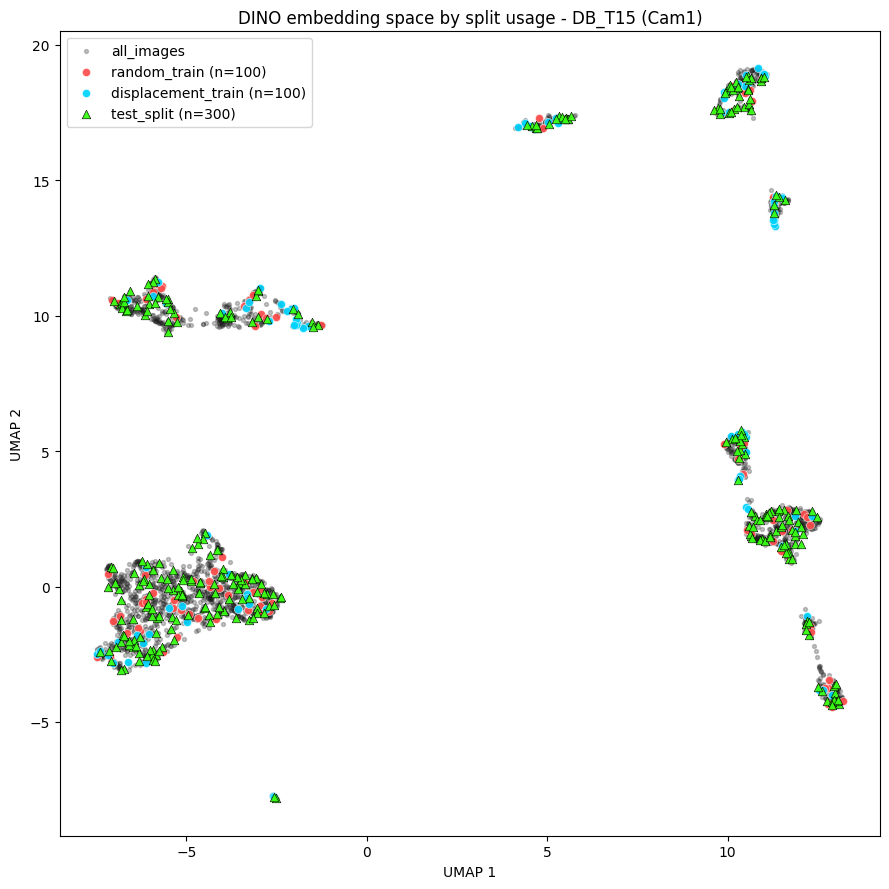

In [2]:
# Cell-67-style scatter overlay: dark background cloud + bright split selections
plt.figure(figsize=(9, 9))

# All images (background)
plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    s=8,
    alpha=0.25,
    c="#1b1b1b",
    label="all_images",
)

overlay_specs = [
    ("random", "#ff4d4d"),
    ("displacement", "#00d4ff"),
    ("dino", "#ffd60a"),
]

for method_name, color in overlay_specs:
    idx = method_to_indices.get(method_name, np.asarray([], dtype=int))
    if idx.size == 0:
        continue
    plt.scatter(
        embedding_2d[idx, 0],
        embedding_2d[idx, 1],
        s=34,
        alpha=0.92,
        c=color,
        edgecolors="white",
        linewidths=0.35,
        label=f"{method_name}_train (n={idx.size})",
    )

if test_indices.size > 0:
    plt.scatter(
        embedding_2d[test_indices, 0],
        embedding_2d[test_indices, 1],
        s=38,
        alpha=0.95,
        c="#39ff14",
        marker="^",
        edgecolors="black",
        linewidths=0.45,
        label=f"test_split (n={test_indices.size})",
    )

plt.legend(loc="best", frameon=True)
plt.title(f"DINO embedding space by split usage - {TRIAL_FOR_EMBED_VIS} ({CAMERA_FOR_EMBED_VIS})")
plt.xlabel("UMAP 1" if umap is not None else "PC 1")
plt.ylabel("UMAP 2" if umap is not None else "PC 2")
plt.tight_layout()
plt.show()